[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Optimizer077/jev-learning-course/blob/main/notebooks/10_pytorch_models_lab.ipynb)

# 10 · Train six small models with PyTorch

**Path:** Optional PyTorch builder  
**Before you start:** Lessons 02 and 07; basic Python; PyTorch only for running

[Course home](../README.md) · [Course outline](../docs/COURSE.md) · [Setup help](../docs/SETUP.md) · [Glossary](../docs/GLOSSARY.md)

## The idea before the code

Train six real, small neural models. A model can learn only from the information its input preserves. Compare both ordinary accuracy and whether it gets both reversed sentences right.

**Your first pass:** Read the input-format and model tables, trace one update, then inspect the saved curves and paired results. Training and checkpoint code can wait for your second pass.

### Words you need for this lesson

| Word | Everyday meaning |
|---|---|
| **Tensor** | An array PyTorch can use in calculations and gradient tracking. |
| **Gradient** | How a small weight change affects the loss. |
| **Checkpoint** | A saved set of model weights. |
| **Embedding** | A learned numerical vector representing a token. |

## Goal
Train real, small PyTorch models and see how their **input representation** changes what they
can learn. You will trace one weight update, compare six implementations across three seeds,
and inspect a sentence pair rather than trusting an aggregate score.

**45–60 minutes · optional builder path.** Basic Python and lessons 02 and 07 help.
Reading the saved results is enough for a first pass. All training uses a CPU; no pretrained
weights, account, Jev key, or GPU is used.

This is a **general ML experiment**, not a Jev implementation or model-family benchmark.
Its sentences and labels are deliberately authored for a small word-order task.

**What the saved Windows run shows:** all three order-blind models get **86/172 cases** right
but **0/86 complete pairs**. CNN and GRU get 172/172 in all three seeds; the tiny Transformer
gets 170–172/172. These are outcomes of this authored grammar and fixed settings, not a ranking
of model families. Read the pair inspection to explain the difference.

## Setup
If PyTorch is absent, install the [optional CPU requirements](../docs/requirements-torch.txt)
in your course environment. In Colab, PyTorch is usually already available. If needed, run
`%pip install torch` in a separate cell, then restart and Run All. See [setup](../docs/SETUP.md).

**Fixed experiment:** 80 full-batch epochs, Adam with learning rate 0.01, CPU with one thread,
and training seeds 7, 19, 41. Checkpoints use validation loss. Architecture and settings are
fixed for this teaching demonstration, not optimized on test outcomes.

In [1]:
# Find the included teaching helpers from the course folder.
from pathlib import Path
import sys
REQUIRED_FILES = ("src/lab_core.py", "src/tutorial_utils.py", "src/torch_lab.py",
                  "data/tickets.json", "data/torch_toy.json",
                  "assets/decision-flow.png", "assets/question-types.png",
                  "assets/calibration-counts.png", "assets/data-splits.png", "assets/word-order.png")
COURSE_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                    if all((p / name).is_file() for name in REQUIRED_FILES)), None)
# Colab opens a single notebook; fetch its companion code and fictional data.
if COURSE_ROOT is None:
    try:
        import google.colab
    except ImportError:
        pass
    else:
        import subprocess
        COURSE_ROOT = Path("/content/jev-learning-course")
        if COURSE_ROOT.exists() and not all((COURSE_ROOT / name).is_file() for name in REQUIRED_FILES):
            raise FileNotFoundError("The cached Colab course is incomplete. Start a fresh runtime and run all again.")
        if not COURSE_ROOT.exists():
            subprocess.run(["git", "clone", "--depth", "1",
                            "https://github.com/Optimizer077/jev-learning-course.git",
                            str(COURSE_ROOT)], check=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Extract the complete course and open it from its folder.")
if str(COURSE_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "src"))

import numpy as np
import matplotlib.pyplot as plt
try:
    import torch
except ImportError as error:
    raise ImportError('Lesson 10 needs PyTorch. Follow docs/SETUP.md, install the optional requirements, then restart and Run All.') from error
from torch import nn
from copy import deepcopy
from matplotlib.ticker import PercentFormatter
from tutorial_utils import setup, table, show_figure
from torch_lab import (LABELS, MODEL_NAMES, SEEDS, load_toy_rows, validate_toy_rows,
                       prepare_data, make_model, train_one, evaluate, predict)
setup()
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
EPOCHS, LEARNING_RATE = 80, 0.01
print('PyTorch:', torch.__version__, '| device: CPU | threads:', torch.get_num_threads())

PyTorch: 2.14.1+cpu | device: CPU | threads: 1


## Steps
### 1. Meet the task before the models
Which issue is failing: **billing**, **technical**, or **account**?

| Evidence | Intended primary queue |
|---|---|
| The payment failed, not the export. | billing |
| The export failed, not the payment. | technical |

The words are the same, but their order changes what is denied. Our generator uses nine issue
words, four short templates, and four prefixes. Each sentence has a reversed partner with a
different label. Both partners stay in the **same** split.

The 864 sentences are separate from lesson 07's 54 tickets. Training, validation, and test
share this controlled grammar; the experiment does **not** test new grammars or real traffic.
The author knows the task construction, so fixed splits do not make this a blinded benchmark.

Split,Sentences,Reversed pairs,Purpose
train,520,260,Learn weights and vocabulary
validation,172,86,Choose a checkpoint
test,172,86,Assess the frozen models


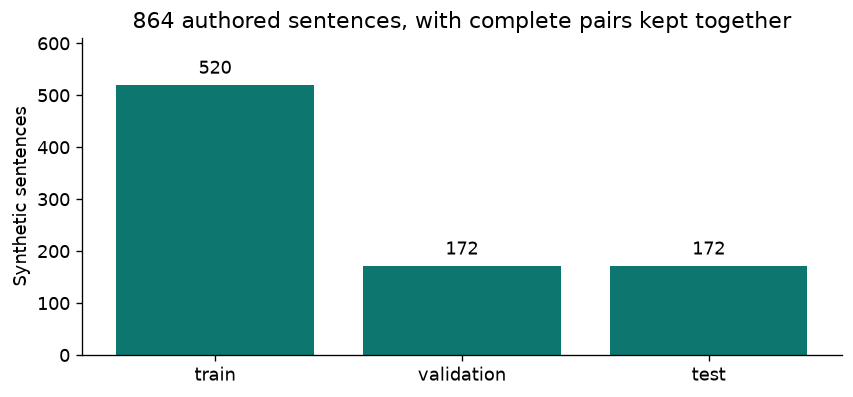

In [2]:
torch_rows = load_toy_rows()
split_counts = validate_toy_rows(torch_rows)
vocab, batches = prepare_data(torch_rows)
table(['Split', 'Sentences', 'Reversed pairs', 'Purpose'], [
    [split, split_counts[split], split_counts[split]//2, purpose]
    for split, purpose in [('train', 'Learn weights and vocabulary'),
                           ('validation', 'Choose a checkpoint'),
                           ('test', 'Assess the frozen models')]])
fig, ax = plt.subplots(figsize=(7, 3.2))
names = ['train', 'validation', 'test']
bars = ax.bar(names, [split_counts[s] for s in names], color='#0d766f')
ax.bar_label(bars, padding=4)
ax.set(ylabel='Synthetic sentences', title='864 authored sentences, with complete pairs kept together', ylim=(0, 610))
show_figure('10_toy_splits')

### 2. Compare the two input formats
All six models receive the **text only** when predicting. Labels are training targets and
evaluation references. The vocabulary is fitted on training text only; unseen words map to
`<unk>`. Padding uses a separate zero token and is masked from pooling.

The bag-of-words matrix says which words appear. The token matrix retains their sequence.
**Predict:** which matrix can distinguish the reversed pair?

In [3]:
train_batch = batches['train']
pair_batch = {key: value[:2] for key, value in train_batch.items()}
table(['Message', 'Reference label'], [[row['text'], row['label']] for row in pair_batch['rows']])
inverse_vocab = {index: word for word, index in vocab.items()}
for row_index in range(2):
    print('Token order', row_index+1, ':',
          [inverse_vocab[int(i)] for i in pair_batch['tokens'][row_index] if int(i) != 0])
print('Identical word-presence vectors:', torch.equal(pair_batch['bow'][0], pair_batch['bow'][1]))
print('Identical token sequences:', torch.equal(pair_batch['tokens'][0], pair_batch['tokens'][1]))
table(['Tensor', 'Shape', 'Type', 'Meaning'], [
    ['bow', tuple(train_batch['bow'].shape), str(train_batch['bow'].dtype), 'case × vocabulary'],
    ['tokens', tuple(train_batch['tokens'].shape), str(train_batch['tokens'].dtype), 'case × padded position'],
    ['labels', tuple(train_batch['labels'].shape), str(train_batch['labels'].dtype), 'one reference class index per case']])

Message,Reference label
"The payment failed, not the export.",billing
"The export failed, not the payment.",technical


Token order 1 : ['the', 'payment', 'failed', 'not', 'the', 'export']
Token order 2 : ['the', 'export', 'failed', 'not', 'the', 'payment']
Identical word-presence vectors: True
Identical token sequences: False


Tensor,Shape,Type,Meaning
bow,"(520, 29)",torch.float32,case × vocabulary
tokens,"(520, 24)",torch.int64,case × padded position
labels,"(520,)",torch.int64,one reference class index per case


### 3. Trace one real PyTorch update
A linear layer gives three **logits**, or raw class scores. `CrossEntropyLoss` handles the
log-softmax internally. Give it the logits and integer reference labels; do not softmax first.
`backward()` computes gradients; `step()` changes weights. These are separate operations.

This four-case warm-up has its **own model**. It does not alter the later comparison.

In [4]:
torch.manual_seed(SEEDS[0])
warm_model = nn.Linear(len(vocab), len(LABELS))
warm_optimizer = torch.optim.SGD(warm_model.parameters(), lr=0.05)
warm_inputs, warm_targets = train_batch['bow'][:4], train_batch['labels'][:4]
weights_before = warm_model.weight.detach().clone()
warm_logits = warm_model(warm_inputs)
warm_loss = nn.CrossEntropyLoss()(warm_logits, warm_targets)
warm_optimizer.zero_grad()
warm_loss.backward()
gradient_norm = float(warm_model.weight.grad.norm())
warm_optimizer.step()
with torch.no_grad():
    loss_after = float(nn.CrossEntropyLoss()(warm_model(warm_inputs), warm_targets))
table(['Check', 'Observed value'], [
    ['Logit shape', tuple(warm_logits.shape)], ['Loss before update', f'{float(warm_loss.detach()):.4f}'],
    ['Gradient norm', f'{gradient_norm:.4f}'], ['Loss after update', f'{loss_after:.4f}'],
    ['Weights changed', not torch.equal(weights_before, warm_model.weight.detach())]])

Check,Observed value
Logit shape,"(4, 3)"
Loss before update,1.2093
Gradient norm,0.9665
Loss after update,1.1541
Weights changed,True


### 4. Choose six ways to represent the message

**BoW** means bag of words. **MLP** means multilayer perceptron, a feedforward network with a
hidden layer. **CNN** means convolutional neural network. **GRU** means gated recurrent unit.
Learn what information each receives before learning the names of its layers.

| Model | How it represents text | Can represent word order? |
|---|---|---|
| BoW linear | Word presence → one linear layer | No |
| BoW MLP | Same word presence → hidden layer → scores | No; extra layers do not restore the missing order |
| Mean embedding | Learn a vector per word, then average | No; averaging removes order |
| CNN | Slide a three-token filter over the sequence | Local order |
| GRU | Update a hidden state while reading the sequence | Yes |
| Transformer | Attention over token vectors plus position vectors | Yes, because positions are supplied |

All are `nn.Module` implementations in [torch_lab.py](../src/torch_lab.py). Learn the linear layer
first; read one sequence class when ready. **Capacity** to distinguish a pair does not guarantee
that a particular training run learns it. The table below exposes different parameter counts.

In [5]:
table(['Model', 'Trainable parameters', 'Input'], [
    [name, sum(p.numel() for p in make_model(name, len(vocab)).parameters()),
     'word presence' if name.startswith('BoW') else 'sequence, then unordered average' if name == 'Mean embedding' else 'token sequence']
    for name in MODEL_NAMES])

Model,Trainable parameters,Input
BoW linear,90,word presence
BoW MLP,795,word presence
Mean embedding,515,"sequence, then unordered average"
CNN,1715,token sequence
GRU,3563,token sequence
Transformer,3123,token sequence


### 5. Train, validate, and freeze the checkpoints
Every model gets 80 full-batch epochs. Each run starts with a fixed seed. We keep the checkpoint
with the lowest **validation** loss, using the earlier epoch for exact ties. No test batch is
passed to the trainer. Validation evaluates weights without gradient updates.

An equal epoch budget is not equal capacity or computation. This is a comparison of six small
implementations under a stated protocol, not a fair ranking of entire model families.

In [6]:
trained = []
for name in MODEL_NAMES:
    for seed in SEEDS:
        trained.append(train_one(name, len(vocab), batches['train'], batches['validation'],
                                 seed, epochs=EPOCHS, learning_rate=LEARNING_RATE))
    print(f'{name}: completed all {len(SEEDS)} training seeds.')
print('Frozen runs:', len(trained), '| test has not been scored in this training step.')

BoW linear: completed all 3 training seeds.


BoW MLP: completed all 3 training seeds.


Mean embedding: completed all 3 training seeds.


CNN: completed all 3 training seeds.


GRU: completed all 3 training seeds.


Transformer: completed all 3 training seeds.
Frozen runs: 18 | test has not been scored in this training step.


### 6. Read the learning curves before the test score
The solid line is training loss; the dashed line is validation loss. Both are evaluated **after
the same update** at each epoch. The dot marks the chosen checkpoint for the first seed.
The other two seeds remain in the final result table.

**Predict:** should an order-blind model solve every paired sentence after more epochs?

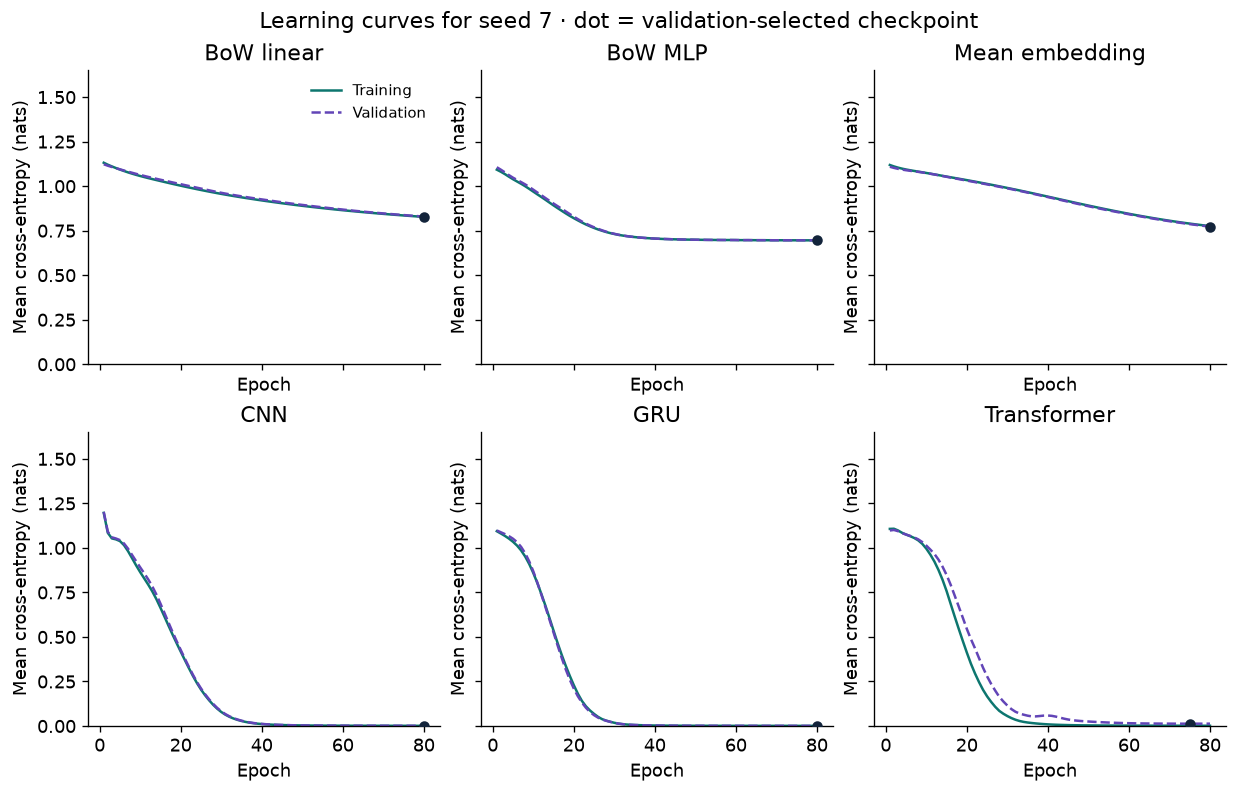

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(10.2, 6.5), sharex=True, sharey=True)
for ax, name in zip(axes.flat, MODEL_NAMES):
    run = next(r for r in trained if r['name'] == name and r['seed'] == SEEDS[0])
    epochs = np.arange(1, EPOCHS+1)
    ax.plot(epochs, run['history'][:, 0], color='#0d766f', label='Training')
    ax.plot(epochs, run['history'][:, 1], color='#6245b7', linestyle='--', label='Validation')
    ax.scatter([run['best_epoch']], [run['validation_loss']], color='#13243b', s=28, zorder=3)
    ax.set(title=name, xlabel='Epoch', ylabel='Mean cross-entropy (nats)', ylim=(0, 1.65))
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle(f'Learning curves for seed {SEEDS[0]} · dot = validation-selected checkpoint')
show_figure('10_training_curves')

**Read the pattern:** a falling loss shows improved fit to this task, not reliable probabilities
on real messages. An order-blind input still maps opposite-reference pairs to the same evidence.
The actual saved curves show what these settings achieved; no architecture is required to win.

### 7. Evaluate every seed on the same held-out cases
Now score the frozen models. Report **correct cases / 172** and **pairs with both correct / 86**.
A pair counts as correct only when both sentences receive their different reference labels.
Order-blind models cannot get both members right, even if their ordinary accuracy looks useful.

**NLL** means negative log-likelihood; it evaluates the reference-class probabilities.
The **Brier score** is a squared probability error. Multiclass Brier here sums squared errors
across three classes, then averages cases (range 0–2). Neither metric alone proves calibration.
Losses are rounded to three decimals; a displayed `0.000` can be a small positive value.

In [8]:
test_results = [dict(run, metrics=evaluate(run['model'], batches['test'])) for run in trained]
table(['Model', 'Seed', 'Chosen epoch', 'Correct cases', 'Both-correct pairs', 'Test NLL', 'Test Brier'], [
    [r['name'], r['seed'], r['best_epoch'], f"{r['metrics']['correct']}/{r['metrics']['total']}",
     f"{r['metrics']['both_correct']}/{r['metrics']['pairs']}",
     f"{r['metrics']['nll']:.3f}", f"{r['metrics']['brier']:.3f}"] for r in test_results])

Model,Seed,Chosen epoch,Correct cases,Both-correct pairs,Test NLL,Test Brier
BoW linear,7,80,86/172,0/86,0.831,0.526
BoW linear,19,80,86/172,0/86,0.834,0.526
BoW linear,41,80,86/172,0/86,0.828,0.525
BoW MLP,7,80,86/172,0/86,0.695,0.500
BoW MLP,19,78,86/172,0/86,0.695,0.500
BoW MLP,41,80,86/172,0/86,0.695,0.500
Mean embedding,7,80,86/172,0/86,0.778,0.511
Mean embedding,19,80,86/172,0/86,0.811,0.524
Mean embedding,41,80,86/172,0/86,0.788,0.516
CNN,7,80,172/172,86/86,0.001,0.000


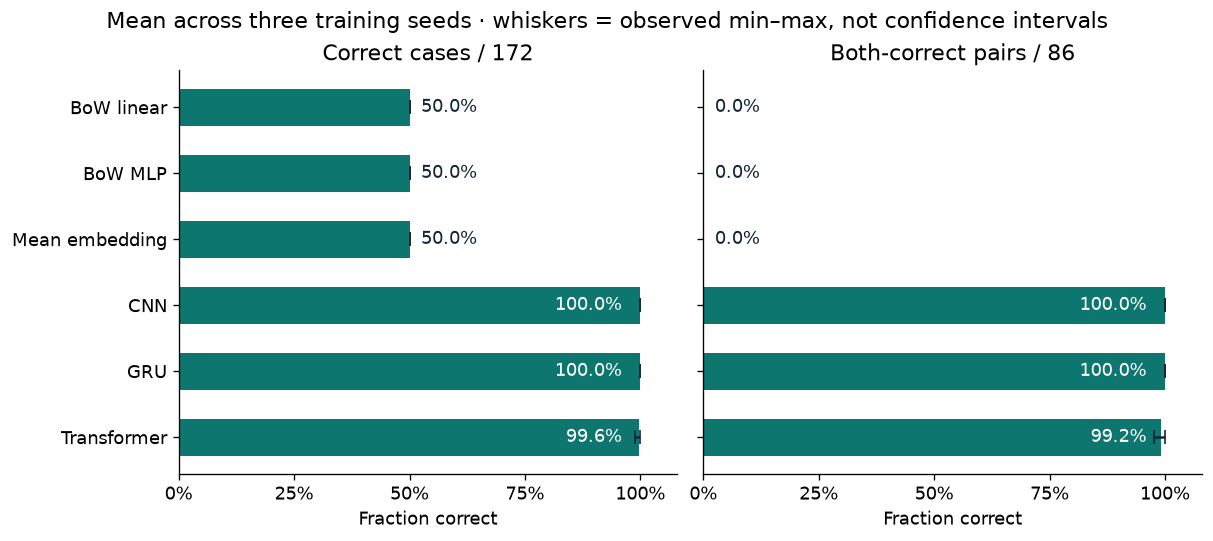

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
for ax, metric, title in zip(axes, ['accuracy', 'pair_accuracy'],
                            ['Correct cases / 172', 'Both-correct pairs / 86']):
    values = np.array([[r['metrics'][metric] for r in test_results if r['name'] == name]
                       for name in MODEL_NAMES])
    means = values.mean(axis=1)
    positions = np.arange(len(MODEL_NAMES))
    ax.barh(positions, means, color='#0d766f', height=0.56)
    ax.errorbar(means, positions, xerr=np.vstack([means-values.min(1), values.max(1)-means]),
                fmt='none', ecolor='#13243b', capsize=4)
    for y, mean in zip(positions, means):
        ax.text(min(mean+0.025, 0.96), y, f'{mean:.1%}', va='center',
                ha='right' if mean>0.9 else 'left', color='white' if mean>0.9 else '#13243b')
    ax.set(xlim=(0, 1.08), yticks=positions, yticklabels=MODEL_NAMES, title=title,
           xlabel='Fraction correct')
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xticks([0, .25, .5, .75, 1])
axes[0].invert_yaxis()
fig.suptitle('Mean across three training seeds · whiskers = observed min–max, not confidence intervals')
show_figure('10_model_comparison')

**Interpretation:** use the exact counts above. The three seeds vary initialization while
holding the test sentences fixed; their range is not uncertainty about new real-world data.
Any high score describes these templates and topic words. Similar results do not establish
similar behavior on unfamiliar grammar, ambiguous messages, or unseen vocabulary.

The order-blind models' **50% case accuracy and 0% both-correct pairs** are the information
ceiling for this balanced paired task, not proof of a broken optimizer. Their loss can improve
by learning which two issues are present, assigning less probability to the unrelated third
queue. The input still cannot tell which of the two is the failing issue.

### 8. Inspect what each model does to one reversed pair
Use the first test pair and the first seed for a readable case inspection. All seeds were
reported above; this inspection does not select the best seed.

In [10]:
test_pair = {key: value[:2] for key, value in batches['test'].items()}
table(['Case', 'Message', 'Reference'], [[i+1, row['text'], row['label']]
                                       for i, row in enumerate(test_pair['rows'])])
pair_observations = []
for name in MODEL_NAMES:
    model = next(r['model'] for r in trained if r['name'] == name and r['seed'] == SEEDS[0])
    logits, probabilities = predict(model, test_pair)
    gap = float((probabilities[0]-probabilities[1]).abs().max())
    pair_observations.append([name, LABELS[int(logits[0].argmax())], LABELS[int(logits[1].argmax())], f'{gap:.3g}'])
    if name in ('BoW linear', 'BoW MLP', 'Mean embedding'):
        assert torch.allclose(logits[0], logits[1], atol=1e-6)
table(['Model', 'Case 1 prediction', 'Case 2 prediction', 'Largest probability change'], pair_observations)

Case,Message,Reference
1,"Customer says: The payment failed, not the export.",billing
2,"Customer says: The export failed, not the payment.",technical


Model,Case 1 prediction,Case 2 prediction,Largest probability change
BoW linear,billing,billing,0
BoW MLP,technical,technical,0
Mean embedding,billing,billing,0
CNN,billing,technical,0.999
GRU,billing,technical,1
Transformer,billing,technical,1


### 9. Remove position information from the Transformer
Copy the trained Transformer and turn off its position vectors. Attention followed by average
pooling becomes invariant to token permutations, apart from floating-point noise.

This is an **information-flow check**, not a retrained architecture comparison. Removing an
input from a model trained with it changes the experiment; do not rank accuracy from this ablation.

In [11]:
position_model = next(r['model'] for r in trained if r['name'] == 'Transformer' and r['seed'] == SEEDS[0])
without_positions = deepcopy(position_model)
without_positions.use_positions = False
with_logits, with_p = predict(position_model, test_pair)
without_logits, without_p = predict(without_positions, test_pair)
table(['Same copied weights', 'Largest probability change between the two sentences'], [
    ['With position vectors', f'{float((with_p[0]-with_p[1]).abs().max()):.4f}'],
    ['Without position vectors', f'{float((without_p[0]-without_p[1]).abs().max()):.4g}']])
assert torch.allclose(without_logits[0], without_logits[1], atol=1e-5)

Same copied weights,Largest probability change between the two sentences
With position vectors,0.9999
Without position vectors,2.91e-10


## Checks
Check splitting, probability accounting, metric calculations, and the information-loss claim.
Do not assert that CNN, GRU, or Transformer must achieve a particular score.

In [12]:
assert dict(split_counts) == {'train': 520, 'validation': 172, 'test': 172}
assert len(trained) == len(MODEL_NAMES)*len(SEEDS) == 18
assert not torch.equal(weights_before, warm_model.weight.detach())
for run in test_results:
    result = run['metrics']
    p, y = result['probabilities'], batches['test']['labels'].numpy()
    assert np.isfinite(p).all() and np.allclose(p.sum(axis=1), 1, atol=1e-6)
    independent_nll = -np.log(p[np.arange(len(y)), y]).mean()
    independent_brier = np.square(p-np.eye(3)[y]).sum(axis=1).mean()
    assert np.isclose(independent_nll, result['nll'], atol=1e-5)
    assert np.isclose(independent_brier, result['brier'], atol=1e-5)
    assert result['total'] == 172 and result['pairs'] == 86
    if run['name'] in ('BoW linear', 'BoW MLP', 'Mean embedding'):
        assert result['both_correct'] == 0 and result['correct'] <= result['total']//2
print('18 trained runs, paired split, normalized outputs, and independently recomputed metrics checked.')

18 trained runs, paired split, normalized outputs, and independently recomputed metrics checked.


### Save and reload the trained weights
The cell below writes all 18 small checkpoints under `dist/torch-checkpoints/` and packages them
as `dist/toy-pytorch-models.zip`. These are toy-task weights, not pretrained language models.
The folder stays out of Git; GitHub's successful workflow offers the ZIP as a separate artifact.

Each file includes its model name, seed, vocabulary, label order, and validation-selected epoch.
Reload with the same class definition and `weights_only=True`; then confirm the scores match.

In [13]:
import json
from zipfile import ZipFile, ZIP_DEFLATED
checkpoint_folder = COURSE_ROOT/'dist'/'torch-checkpoints'
checkpoint_folder.mkdir(parents=True, exist_ok=True)
checkpoint_paths = []
for run in trained:
    filename = run['name'].lower().replace(' ', '_')+f"_seed{run['seed']}.pt"
    path = checkpoint_folder/filename
    torch.save({'state_dict': run['model'].state_dict(), 'model_name': run['name'],
                'seed': run['seed'], 'vocabulary': vocab, 'labels': list(LABELS),
                'best_epoch': run['best_epoch'], 'epochs': EPOCHS,
                'learning_rate': LEARNING_RATE, 'torch_version': str(torch.__version__)}, path)
    checkpoint_paths.append(path)
manifest = {'scope': 'Authored synthetic word-order task; not Jev or a pretrained language model',
            'sentences': len(torch_rows), 'split_counts': dict(split_counts),
            'training_seeds': list(SEEDS), 'checkpoint_files': [p.name for p in checkpoint_paths]}
manifest_path = checkpoint_folder/'manifest.json'
manifest_path.write_text(json.dumps(manifest, indent=2)+'\n', encoding='utf-8')
archive_path = COURSE_ROOT/'dist'/'toy-pytorch-models.zip'
with ZipFile(archive_path, 'w', ZIP_DEFLATED) as archive:
    for path in checkpoint_paths+[manifest_path]:
        archive.write(path, path.name)
reloaded = torch.load(checkpoint_paths[0], map_location='cpu', weights_only=True)
assert reloaded['vocabulary'] == vocab and reloaded['labels'] == list(LABELS)
restored = make_model(reloaded['model_name'], len(reloaded['vocabulary']))
restored.load_state_dict(reloaded['state_dict'])
assert torch.allclose(predict(restored, test_pair)[0], predict(trained[0]['model'], test_pair)[0])
print(f'Saved {len(checkpoint_paths)} small checkpoints and verified a reloaded prediction.')
print('Archive: dist/toy-pytorch-models.zip')

Saved 18 small checkpoints and verified a reloaded prediction.
Archive: dist/toy-pytorch-models.zip


## Next Steps
Complete [Assignment 4](../assignments/04_compare_torch_models.md). Explain one update, one model's
representation, one failure, and one result these synthetic sentences do not establish.

For an extension, change **one** training setting and compare validation results before using
new held-out cases. Write your prediction first. Do not repeatedly choose models by these test scores.
For a stronger study, add unseen grammar and independently authored labels, preserving grouped splits.

For probabilities and action costs, return to [lesson 03](03_calibration_and_decisions.ipynb).
For Jev's actual API contract, use [lesson 05](05_optional_real_jev_api.ipynb).

[Official PyTorch loss reference](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
· [GRU](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html)
· [Transformer encoder](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html).
Local implementation and execution records are inspectable; no provider model was measured here.

## Take three ideas with you

- PyTorch separates scores, loss, gradients, and weight updates.
- Averaging embeddings and adding more layers to word-presence inputs still discard order.
- Choose checkpoints on validation, report every seed, and judge paired failures as well as aggregate accuracy.

**You are ready to move on when:** You can explain an update, identify lost word order, and report all seeds with their test denominators.

## Check your understanding

A larger MLP receives the same word-presence vector for two opposite-label sentences. Can extra layers recover their original word order?

Pause and explain your answer before opening the explanation.

<details>
<summary>Show the explanation</summary>
<p>No. The representation already removed it. A deterministic network receiving the same vector produces the same result. Preserve the relevant information before asking training to use it.</p>
</details>

For a short next step, try the [practice questions](../docs/PRACTICE.md).
For runnable exercises, use the [worked exercises](08_exercises_and_solutions.ipynb).

If you are unsure where to go next, use [the course outline](../docs/COURSE.md).

[Assignments](../assignments/README.md) · [Quick reference](../docs/QUICK_REFERENCE.md) · [Course outline](../docs/COURSE.md)